In [1]:
# Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Paramètres d'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
plt.rcParams['figure.figsize'] = (12, 5)

print("✅ Bibliothèques importées avec succès")

✅ Bibliothèques importées avec succès


# Analyse exploratoire — E-commerce France / Women 2023–2024

## Contexte
Ce notebook réalise l'analyse exploratoire (EDA) du sous-périmètre e-commerce :
- **Pays** : France
- **Département** : Women
- **Période** : 01/01/2023 → 31/12/2024

## Plan
1. Chargement et description des données
2. Contrôles qualité
3. Analyse descriptive
4. Comparaison 2023 vs 2024
5. Calcul des KPIs

## 1. Chargement et description des données

In [2]:
# Chargement du CSV
df = pd.read_csv('../data/thelook_fr_women_2023_2024.csv')

# Dimensions du DataFrame
print(f"Nombre de lignes    : {df.shape[0]:,}")
print(f"Nombre de colonnes  : {df.shape[1]}")
print(f"\nAperçu des premières lignes :")
df.head()

Nombre de lignes    : 1,679
Nombre de colonnes  : 20

Aperçu des premières lignes :


,order_id,order_item_id,product_id,item_created_at,item_status,sale_price,cost,category,department,brand,product_name,order_status,order_created_at,shipped_at,delivered_at,user_id,gender,country,state,city
0,19425,28112,6983,2023-01-01 06:18:03+00:00,Shipped,29.50,16.05,Shorts,Women,Fox,Fox Juniors Momentum Short,Shipped,2022-12-29 10:00:00+00:00,2022-12-30 11:29:00+00:00,NaN,15644,F,France,Centre-Val de Loire,Corquilleroy
1,19425,28113,10597,2023-01-01 06:44:58+00:00,Shipped,20.00,10.00,Intimates,Women,Wacoal,Wacoal Women's B-Smooth Bralette,Shipped,2022-12-29 10:00:00+00:00,2022-12-30 11:29:00+00:00,NaN,15644,F,France,Centre-Val de Loire,Corquilleroy
2,4710,6730,11792,2023-01-03 04:44:50+00:00,Complete,38.00,18.47,Intimates,Women,American Apparel,American Apparel Striped Chiffon Tank,Complete,2023-01-03 08:12:00+00:00,2023-01-03 09:14:00+00:00,2023-01-04 03:03:00+00:00,3853,F,France,Île-de-France,Paris
3,16618,24006,329,2023-01-03 15:13:39+00:00,Complete,27.99,16.40,Tops & Tees,Women,Tri-Mountain,Tri-Mountain Women's 3/4-Sleeve Pique Knit Pol...,Complete,2023-01-03 18:58:00+00:00,2023-01-05 13:23:00+00:00,2023-01-09 10:25:00+00:00,13422,F,France,Hauts-de-France,Comines
4,4710,6731,5295,2023-01-05 06:43:09+00:00,Complete,56.88,29.58,Pants & Capris,Women,Lauren by Ralph Lauren,Lauren Ralph Lauren Velour Pants,Complete,2023-01-03 08:12:00+00:00,2023-01-03 09:14:00+00:00,2023-01-04 03:03:00+00:00,3853,F,France,Île-de-France,Paris


In [6]:
# Description des colonnes
print("Colonnes du DataFrame :")
print(df.columns.tolist())

Colonnes du DataFrame :
['order_id', 'order_item_id', 'product_id', 'item_created_at', 'item_status', 'sale_price', 'cost', 'category', 'department', 'brand', 'product_name', 'order_status', 'order_created_at', 'shipped_at', 'delivered_at', 'user_id', 'gender', 'country', 'state', 'city']


In [7]:
# Affichage complet des colonnes
for i, col in enumerate(df.columns):
    print(f"{i+1:2}. {col}")

 1. order_id
 2. order_item_id
 3. product_id
 4. item_created_at
 5. item_status
 6. sale_price
 7. cost
 8. category
 9. department
10. brand
11. product_name
12. order_status
13. order_created_at
14. shipped_at
15. delivered_at
16. user_id
17. gender
18. country
19. state
20. city


### Dictionnaire de données

In [8]:
# Dictionnaire de données
dictionnaire = {
    'Colonne': [
        'order_id', 'order_item_id', 'product_id', 'item_created_at',
        'item_status', 'sale_price', 'cost', 'category', 'department',
        'brand', 'product_name', 'order_status', 'order_created_at',
        'shipped_at', 'delivered_at', 'user_id', 'gender', 'country',
        'state', 'city'
    ],
    'Type': [
        'int', 'int', 'int', 'datetime',
        'str', 'float', 'float', 'str', 'str',
        'str', 'str', 'str', 'datetime',
        'datetime', 'datetime', 'int', 'str', 'str',
        'str', 'str'
    ],
    'Description': [
        'Identifiant unique de la commande',
        'Identifiant unique de la ligne de commande',
        'Identifiant unique du produit',
        'Date de création de la ligne article',
        'Statut de la ligne article (Complete, Returned...)',
        'Prix de vente du produit (€)',
        'Coût d\'achat du produit (€)',
        'Catégorie du produit (Tops & Tees, Pants...)',
        'Département (Women)',
        'Marque du produit',
        'Nom complet du produit',
        'Statut global de la commande',
        'Date de création de la commande',
        'Date d\'expédition',
        'Date de livraison',
        'Identifiant unique du client',
        'Genre du client',
        'Pays du client',
        'Région/État du client',
        'Ville du client'
    ]
}

pd.DataFrame(dictionnaire)

,Colonne,Type,Description
0,order_id,int,Identifiant unique de la commande
1,order_item_id,int,Identifiant unique de la ligne de commande
2,product_id,int,Identifiant unique du produit
3,item_created_at,datetime,Date de création de la ligne article
4,item_status,str,"Statut de la ligne article (Complete, Returned..."
5,sale_price,float,Prix de vente du produit (€)
6,cost,float,Coût d'achat du produit (€)
7,category,str,"Catégorie du produit (Tops & Tees, Pants...)"
8,department,str,Département (Women)
9,brand,str,Marque du produit


## 2. Contrôles qualité

In [9]:
# Types réels et valeurs manquantes
print("=== TYPES ET VALEURS MANQUANTES ===\n")
info = pd.DataFrame({
    'Type réel': df.dtypes,
    'Valeurs manquantes': df.isnull().sum(),
    '% manquant': (df.isnull().sum() / len(df) * 100).round(2)
})
print(info)

=== TYPES ET VALEURS MANQUANTES ===

                 Type réel  Valeurs manquantes  % manquant
order_id             int64                   0        0.00
order_item_id        int64                   0        0.00
product_id           int64                   0        0.00
item_created_at        str                   0        0.00
item_status            str                   0        0.00
sale_price         float64                   0        0.00
cost               float64                   0        0.00
category               str                   0        0.00
department             str                   0        0.00
brand                  str                   2        0.12
product_name           str                   0        0.00
order_status           str                   0        0.00
order_created_at       str                   0        0.00
shipped_at             str                 546       32.52
delivered_at           str                1043       62.12
user_id            

In [10]:
# Conversion des dates en datetime
date_cols = ['item_created_at', 'order_created_at', 'shipped_at', 'delivered_at']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], utc=True)

# Vérification des doublons
doublons = df.duplicated().sum()

print("=== CONTRÔLE QUALITÉ ===\n")
print(f"✅ Dates converties en datetime : {date_cols}")
print(f"✅ Doublons détectés : {doublons}")
print(f"\nTypes après conversion :")
print(df[date_cols].dtypes)

=== CONTRÔLE QUALITÉ ===

✅ Dates converties en datetime : ['item_created_at', 'order_created_at', 'shipped_at', 'delivered_at']
✅ Doublons détectés : 0

Types après conversion :
item_created_at     datetime64[us, UTC]
order_created_at    datetime64[us, UTC]
shipped_at          datetime64[us, UTC]
delivered_at        datetime64[us, UTC]
dtype: object


In [11]:
# Vérification de la cohérence des périodes
print("=== COHÉRENCE DES PÉRIODES ===\n")
print(f"Date min : {df['item_created_at'].min()}")
print(f"Date max : {df['item_created_at'].max()}")
print(f"\nRépartition par année :")
print(df['item_created_at'].dt.year.value_counts().sort_index())
print(f"\nStatuts présents :")
print(df['item_status'].value_counts())

=== COHÉRENCE DES PÉRIODES ===

Date min : 2023-01-01 06:18:03+00:00
Date max : 2024-12-31 10:40:48+00:00

Répartition par année :
item_created_at
2023    711
2024    968
Name: count, dtype: int64

Statuts présents :
item_status
Shipped       497
Complete      425
Processing    306
Cancelled     240
Returned      211
Name: count, dtype: int64


In [12]:
# Commentaire explicite sur les conventions appliquées
print("=== CONVENTION MÉTIER APPLIQUÉE ===\n")

df_ventes = df[df['item_status'] == 'Complete']
df_retours = df[df['item_status'] == 'Returned']

print(f"Lignes 'Complete' (ventes) : {len(df_ventes)}")
print(f"Lignes 'Returned' (retours) : {len(df_retours)}")
print(f"Lignes exclues des KPI      : {len(df) - len(df_ventes) - len(df_retours)}")
print(f"\n✅ Périmètre KPI = {len(df_ventes) + len(df_retours)} lignes sur {len(df)} au total")

=== CONVENTION MÉTIER APPLIQUÉE ===

Lignes 'Complete' (ventes) : 425
Lignes 'Returned' (retours) : 211
Lignes exclues des KPI      : 1043

✅ Périmètre KPI = 636 lignes sur 1679 au total


## 3. Analyse descriptive

### Distribution des prix de vente et des coûts

In [13]:
# Statistiques descriptives sur les prix et coûts (lignes Complete uniquement)
print("=== STATISTIQUES DESCRIPTIVES ===\n")
stats = df_ventes[['sale_price', 'cost']].describe().round(2)
stats.loc['marge_moyenne'] = (df_ventes['sale_price'] - df_ventes['cost']).describe().round(2)
print(stats)

=== STATISTIQUES DESCRIPTIVES ===

               sale_price   cost
count              425.00 425.00
mean                55.35  26.62
std                 71.41  33.70
min                  1.82   0.75
25%                 18.97   8.74
50%                 36.29  17.97
75%                 62.36  29.58
max                903.00 437.05
marge_moyenne         NaN    NaN


In [14]:
# Statistiques corrigées + marge
print("=== STATISTIQUES DESCRIPTIVES ===\n")

stats = df_ventes[['sale_price', 'cost']].describe().round(2)
print(stats)

marge = df_ventes['sale_price'] - df_ventes['cost']
print(f"\n=== MARGE BRUTE PAR ARTICLE ===")
print(f"Marge moyenne  : {marge.mean():.2f} €")
print(f"Marge médiane  : {marge.median():.2f} €")
print(f"Marge min      : {marge.min():.2f} €")
print(f"Marge max      : {marge.max():.2f} €")

=== STATISTIQUES DESCRIPTIVES ===

       sale_price   cost
count      425.00 425.00
mean        55.35  26.62
std         71.41  33.70
min          1.82   0.75
25%         18.97   8.74
50%         36.29  17.97
75%         62.36  29.58
max        903.00 437.05

=== MARGE BRUTE PAR ARTICLE ===
Marge moyenne  : 28.73 €
Marge médiane  : 18.47 €
Marge min      : 1.07 €
Marge max      : 465.95 €


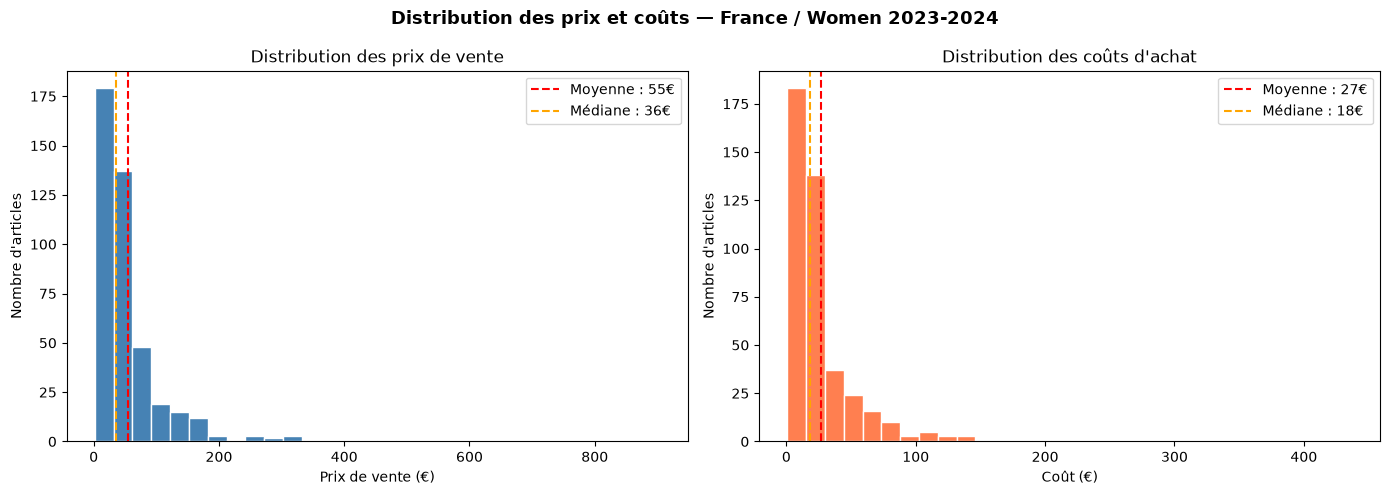

✅ Graphique sauvegardé


In [15]:
# Distribution des prix et coûts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prix de vente
axes[0].hist(df_ventes['sale_price'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(df_ventes['sale_price'].mean(), color='red', linestyle='--', label=f"Moyenne : {df_ventes['sale_price'].mean():.0f}€")
axes[0].axvline(df_ventes['sale_price'].median(), color='orange', linestyle='--', label=f"Médiane : {df_ventes['sale_price'].median():.0f}€")
axes[0].set_title("Distribution des prix de vente")
axes[0].set_xlabel("Prix de vente (€)")
axes[0].set_ylabel("Nombre d'articles")
axes[0].legend()

# Coût
axes[1].hist(df_ventes['cost'], bins=30, color='coral', edgecolor='white')
axes[1].axvline(df_ventes['cost'].mean(), color='red', linestyle='--', label=f"Moyenne : {df_ventes['cost'].mean():.0f}€")
axes[1].axvline(df_ventes['cost'].median(), color='orange', linestyle='--', label=f"Médiane : {df_ventes['cost'].median():.0f}€")
axes[1].set_title("Distribution des coûts d'achat")
axes[1].set_xlabel("Coût (€)")
axes[1].set_ylabel("Nombre d'articles")
axes[1].legend()

plt.suptitle("Distribution des prix et coûts — France / Women 2023-2024", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/viz_distribution_prix_couts.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé")

**Constats :**
- La majorité des articles vendus ont un prix inférieur à 200€
- La distribution est asymétrique à droite : quelques articles premium (jusqu'à 903€) tirent la moyenne au-dessus de la médiane
- Même observation sur les coûts : la médiane (18€) est bien inférieure à la moyenne (27€)
- **Recommandation** : utiliser la médiane plutôt que la moyenne pour caractériser le prix "typique" d'un article

**Choix du graphique :**
- **Histogramme** choisi pour visualiser la distribution d'une variable continue
- Les lignes moyenne/médiane permettent de repérer immédiatement l'asymétrie
- Alternative possible : boxplot (meilleure lisibilité des outliers)